# Primary Productivity Absolute Relative Difference Analysis  
## Absolute Relative difference analysis of the interim and legacy products
> History | Updated Nov 2024  

## Objectives
Calculate the mean absolute relative difference (&Delta;<sub>rel</sub>) of the interim VIIRS netPP product (netPP<sub>VIIRS</sub>) and legacy MODIS netPP product (netPP<sub>MODIS</sub>) for each month from a timeseries dependent on the user-specified VIIRS sensor.

For **VIIRS-SNPP**, the result will be a **120-month (10-year)** mean monthly timeseries of &Delta;<sup>netPP</sup> within your area of interest.

For **VIIRS-NOAA20**, the result will be a **60-month (5-year)** mean monthly timeseries of &Delta;<sup>netPP</sup> within your area of interest.

* &Delta;<sub>rel</sub> was calculated as the difference between VIIRS-SNPP (netPP<sub>VIIRS</sub>) and MODIS-Aqua netPP (netPP<sub>MODIS</sub>)  values divided by netPP<sub>MODIS</sub>. 
 
* Normalizing by netPP<sub>MODIS</sub> allow users to evaluate how much difference to expect in the netPP values used in their applications when switching to the interim product.  

### Steps:    
> * Download an area of monthly  &Delta;<sub>rel</sub> values from the ERDDAP server for each month from the timeseries.  
> * Calculate the mean values of &Delta;<sub>rel</sub> for each month. 
> * Visualized the timeseries and save the data.
> * Visualize the spatial variability in the timeseries monthly &Delta;<sup>lat/lon</sup> mean.

## Satellite Datasets:  
#### Absolute Relative Difference
The absolute relative difference (&Delta;<sup>netPP</sup>) is calculated, for each pixel as follows:

$
\Large\Delta^{netPP} = \frac{netPP_{VIIRS} - netPP_{MODIS}}{netPP_{MODIS}}\
$  

Where:
* The difference between VIIRS and MODIS values for that pixel is divided by MODIS values.  


#### Datasets Overview

We created the pixel-by-pixel unbiased relative difference (&Delta;<sup>netPP</sup>) for the globe for each monthy at a 9km resolution across two datasets:

1. **VIIRS-SNPP - MODIS-Aqua Global, Monthly, 9km, 2013-2022**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/netpp_delta_snpp_modis.graph

2. **VIIRS-NOAA20 - MODIS-Aqua Global, Monthly, 9km, 2018-2022**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/netpp_delta_noaa20_modis.graph

#### Tutorial for this notebook

The VIIRS/SNPP - MODIS/Aqua dataset will be used in this notebook to generate a timeseries of monthly mean values of &Delta;<sup>netPP</sup>. We will access the data using the xr_open_ds() function below. The function requires:  
* The url of the ERDDAP server being use, in this case: https://coastwatch.pfeg.noaa.gov/wcn/erddap

* The ID of the dataset, in this case "netpp_delta_snpp_modis".

**To use the VIIRS-NOAA20 sensor instead,** set 'sensor = "noaa20"' in the code below.


## Import necessary packages

In [2]:
import os
import subprocess
from datetime import timezone, datetime
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from netCDF4 import Dataset

# added necessary packages
from dateutil import rrule
from dateutil.parser import parse
import xarray as xr
import pandas as pd

## Create Global Variables

In [ ]:
ROOT_DIR = ("/Users/madisonrichardson/netpp")
VIIRS_DIR_T = os.path.join(ROOT_DIR, "data/{}/monthly/netpp")
MODIS_DIR = os.path.join(ROOT_DIR, "data/modis/monthly_netpp")
WORK_DIR = os.path.join(ROOT_DIR, 'work')
BIN_DIR = os.path.join(ROOT_DIR, 'bin')
RES_DIR = os.path.join(ROOT_DIR, 'resources')
NC_OUT_DIR_T = os.path.join(ROOT_DIR, "data/{}/matrix/delta")
CDL_IN_FILE = 'delta_nasa_9k.cdl'
TEMP_OUT_FILE = 'tempoutfiledelta.nc'
NCO_DIR = '/Users/madisonrichardson/miniforge3/bin/'

In [ ]:
ROOT_DIR = "/Users/madisonrichardson/netpp"
ODATA_DIR_T = os.path.join(ROOT_DIR, "data/{}/matrix/delta")
WORK_DIR = os.path.join(ROOT_DIR, "work")
RESOURCES_DIR = os.path.join(ROOT_DIR, "resources")

## Make Useful Functions

In [ ]:
def xr_open_ds(
    e_id, e_source="https://coastwatch.pfeg.noaa.gov/wcn/erddap", dap="griddap"
):
    """
    Open a remote ERDDAP dataset as an Xarray dataset.

    Constructs the ERDDAP dataset URL using the provided dataset ID ('e_id'),
    server URL ('e_source'), and data access protocol ('dap'). Then it uses Xarray
    to open the dataset from the remote source.

    Args:
        e_id (str): ERDDAP dataset ID.
        e_source (str, optional): URL to ERDDAP server. Defaults to 'https://coastwatch.pfeg.noaa.gov/'.
            You can change it to any ERDDAP server.
        dap (str, optional): The data access protocol type. Defaults to 'griddap' which is used for
        accessing gridded datasets.

    Returns:
        array: Xarray dataset object
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = "/".join([e_source, dap, e_id])

    return xr.open_dataset(erddap_url)

In [ ]:
def make_ncfile_from_cdl_dr(path_cdl, path_ncfile, nco_path):
    """
    Make a NetCDF file from a CDL (Common Data Language) file
    template using the ncgen tool.

    Args:
        path_cdl (str): The path to the input CDL file that defines
                        the structure of the NetCDF file.
        path_ncfile (str): The path to the output NetCDF file that
                            will be created by ncgen.
        nco_path (str): The path to the directory containing the
                        NCO (NetCDF Operators) tools such as ncgen
                        to make the NetCDF file from the CDL file.
    """
    myCmd = ' '.join([os.path.join(nco_path, 'ncgen'),
                      '-o', path_ncfile,
                      path_cdl])
    
    print("Generated NetCDF template",
          subprocess.call(myCmd, shell=True))  # prints zero if myCmd is success

In [ ]:
def calculate_relative_diff(minuend_data, subtrahend_data):
    """
    Calculate the relative difference (delta) between the two
    datasets.

    Nerd Notation
    minuend is math-speak for the value substracted from.

    subtrahend is math-speak for the value that is substracted.

    Args:
        minuend_data (ma.MaskedArray): The dataset where values will be
                                    subtracted.
        subtrahend_data (ma.MaskedArray): The dataset that will be subtracted
                                        from 'minuend_data'.

    Returns:
        ma.MaskedArray: The array of relative difference values
                        where missing data remains masked.
    """

    # Calculate relative difference (delta)
    delta = ma.divide(ma.subtract(minuend_data, subtrahend_data), subtrahend_data)

    return delta

In [ ]:
def get_nc_var_data_dr(file1_path, my_var):
    """
    Extract data from specified variable in a NetCDF file.

    Args:
        file1_path (str): The full path to the NetCDF file from
                            where the data is extracted.
        my_var (str): The name of the variable in the NetCDF file
                        to extract (e.g., 'productivity).

    Returns:
        netpp_file1 (numpy.ndarray): A 2D array (latitude, longitude) containing
        the data for the first time step of the specified variable.
    """
    
    file1 = Dataset(file1_path, 'r')

    # Extract NetPP data
    netpp_file1 = file1.variables[my_var][0, :, :]
    
    # Close the VIIRS and MODIS files
    file1.close()
    
    return netpp_file1

In [ ]:
def plot_monthly_delta_timeseries(dates, delta_mean, ymin=-0.1, ymax=0.1):
    """
    Plot the monthly mean relative difference time series.

    Args:
        dates (pd.DatetimeIndex): Dates centered on the 16th of each month.
        delta_mean (xarray.DataArray or 1D array): Monthly mean ΔnetPP values.
        ymin (float): Lower y-axis limit.
        ymax (float): Upper y-axis limit.
    """
    plt.figure(figsize=(20, 6))
    plt.plot(dates, delta_mean, 'b--', label=r'$\bar{\Delta}_{month}$')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axhline(0.05, color='red', linestyle=':', linewidth=1)
    plt.axhline(-0.05, color='red', linestyle=':', linewidth=1)
    plt.ylim(ymin, ymax)

    plt.title(r'$\bar{\Delta}_{month}$ Timeseries: Relative Difference', fontsize=14)
    plt.ylabel('Unbiased Relative Difference (%)', fontsize=12)
    plt.xlabel('Time', fontsize=12)

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gcf().autofmt_xdate()

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

In [ ]:
def plot_spatial_delta_mean(my_date, ds, da, title=None, vmin=-0.25, vmax=0.25):
    """
    Plot the spatial mean ΔnetPP across time.

    Args:
        ds (xarray.Dataset): Dataset containing coordinates (longitude, latitude).
        da (xarray.DataArray): ΔnetPP data array with dimensions (time, lat, lon).
        title (str): Optional plot title.
        vmin (float): Minimum value for color scale.
        vmax (float): Maximum value for color scale.
    """
    
    # Assign the centered time back to the dataset
    da['time'] = my_date

    delta_mean = da.mean(dim="time", skipna=True).values

    plt.figure(figsize=(10, 6))
    plt.pcolormesh(ds.longitude, ds.latitude, delta_mean, cmap='coolwarm', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar()
    cbar.set_label(r'$\bar{\Delta}_{lat/lon}$ (percent)')

    if title:
        plt.title(title, fontsize=14)
    else:
        plt.title(r'$\bar{\Delta}_{lat/lon}$ Spatial Variability', fontsize=14)

    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

## Parameter Setup

In [ ]:
# Set the parameters
start_yr_mo = '2013-01'
end_yr_mo = '2022-12'
sensor = 'snpp'
netpp_var = 'productivity'
overwrite = True

start_date = parse(start_yr_mo).replace(day=16)
end_date = parse(end_yr_mo).replace(day=16)
print(start_date, end_date)

In [ ]:
# Define sensor (either "snpp" or "noaa20" or "modis")
sensor1 = "modis"
sensor2 = "noaa20"

# Valid sensors list
valid_sensors = {"modis", "snpp", "noaa20"}

# Check both sensors are valid
for s in (sensor1, sensor2):
    if s not in valid_sensors:
        raise ValueError(f"The sensor '{s}' is not a valid option. Choose from: {valid_sensors}")

# Set the url of the ERDDAP server
erddap_url = "http://localhost:8080/erddap"

# Set the ERDDAP dataset ID for each sensor
erddap_id1 = f"productivity_modis_aqua_monthly"
erddap_id2 = f"productivity_viirs_{sensor2}_monthly"

print(f"Sensor 1: {sensor1.upper()}, Dataset ID: {erddap_id1}")
print(f"Sensor 2: {sensor2.upper()}, Dataset ID: {erddap_id2}")

## Directory Setup

In [ ]:
# Create dynamic directories and verify
ODATA_DIR = ODATA_DIR_T.format(sensor1)

In [ ]:
# Create dynamic directories and verify
VIIRS_DIR = VIIRS_DIR_T.format(sensor)
NC_OUT_DIR = NC_OUT_DIR_T.format(sensor)

DIR_LIST = [ROOT_DIR,
            WORK_DIR,
            RES_DIR,
            VIIRS_DIR,
            MODIS_DIR,
            NC_OUT_DIR,
            NCO_DIR
            ]

for dr in DIR_LIST:
    os.makedirs(dr, exist_ok=True)
print(len(DIR_LIST), 'directories validated')

## Define Time Range and Output File Path

In [ ]:
## USE THIS ONE 


# Define the final output file path
nc_filename = f'netpp_delta_{sensor}_{sensor2}.nc'
nc_file_path = os.path.join(NC_OUT_DIR, nc_filename)

# Add logic to not overwrite existing files
if os.path.isfile(nc_file_path):
    if not overwrite:
        print(f'{nc_filename} already exists for {sensor1} and {sensor2}')
    else:
        print(f'Overwriting {nc_filename} for {sensor1} and {sensor2}')

In [ ]:
yr_mo_to_bin = rrule.rrule(rrule.MONTHLY, dtstart=start_date, until=end_date)  
yr_mo_to_bin = list(yr_mo_to_bin)

# Define the final output file path
nc_filename = f'netpp_delta_{sensor}_modis.nc'
nc_file_path = os.path.join(NC_OUT_DIR, nc_filename)

# Add logic to not overwrite existing files
if os.path.isfile(nc_file_path):
    if not overwrite:
        print(f'{nc_filename} already exists for {sensor}')
    else:
        print(f'Overwriting {nc_filename} for {sensor}')

## Create Initial NetCDF file

In [ ]:
# Generate the initial NetCDF template from CDL for all years
make_ncfile_from_cdl_dr(os.path.join(RES_DIR, CDL_IN_FILE), 
                        os.path.join(WORK_DIR, nc_file_path),
                        NCO_DIR
                        )

## Prepare and Run ncgen Command

Generate an initial NetCDF file using the 'ncgen' tool and a CDL template.

- Creates filenames for the output NetCDF ('ncgen_ofile_nc') and CDL input ('ncgen_ifile_cdl').

- Constructs a shell command for 'ncegn' to convert the CDL file into a NetCDF file.

- Executes the command using 'subprocess.call' and checks for errors.

In [ ]:
# USE THIS ONE 


# Prepare ncgen input and output filenames
now = datetime.now()
ncgen_ofile_nc = f"ncgen_trend_ofile{now:%Y%m%d%H%M%S}.nc"

# Create temporary file to accept output data from a .cdl file
ncgen_ifile_cdl = 'delta_nasa_9k.cdl'

# Run ncgen command
myCmd1 = " ".join(
    [
        "ncgen",
        "-o",
        os.path.join(WORK_DIR, ncgen_ofile_nc),
        os.path.join(RES_DIR, ncgen_ifile_cdl),
    ]
)
print(myCmd1)
print("ncgen", subprocess.call(myCmd1, shell=True))

## Calculate delta

In [ ]:
delta_results = []



## Process Monthly Files and Populate NetCDF

In [ ]:
# Name of variable in NetPP file
netpp_var = 'productivity'

nc_file = Dataset(nc_file_path, 'a', format='NETCDF4')

time_index = 0
for dt in yr_mo_to_bin:
    file_date = '{0:%Y%m}'.format(dt)
    print("Processing", file_date)
    
    # VIIRS file path depends on the sensor
    if sensor == 'snpp':
        viirs_file_path = os.path.join(VIIRS_DIR,
                                        f"productivity_month_nasa_{file_date}_9km.nc")
    elif sensor == 'noaa20':
        viirs_file_path = os.path.join(VIIRS_DIR,
                                        f"productivity_month_noaa20_{file_date}_9km.nc")
    else:
        raise ValueError("Unknown sensor type. Must be 'snpp' or 'noaa20'")
    
    modis_file_path = os.path.join(MODIS_DIR,
                                    f"productivity_month_modis_{file_date}_9km.nc")

    # Check if both VIIRS and MODIS files exist
    if not os.path.exists(viirs_file_path) or not os.path.exists(modis_file_path):
        print(f"Files for {file_date} are missing! Skipping...")
        continue

    viirs_npp = get_nc_var_data_dr(viirs_file_path, netpp_var)
    modis_npp = get_nc_var_data_dr(modis_file_path, netpp_var)
    
    if viirs_npp.shape != modis_npp.shape:
        err_msg = ("Dimension mismatch. Viirs shape: " 
                    f"{viirs_npp.shape}, Legacy shape: "
                    f"{modis_npp.shape}"
                    )
        raise ValueError(err_msg)
        print("Skipping...", file_date)
        continue
    
    delta = calculate_relative_diff(viirs_npp, modis_npp)
    print('relative difference calculated for', file_date)

    dt = dt.replace(tzinfo=timezone.utc)

    nc_file['time'][time_index] = dt.timestamp()
    nc_file['delta'][time_index, :, :] = delta[:, :]
    nc_file.sync()
    print(file_date, 'data saved to nc file')
    
    time_index += 1

nc_file.close()

## Compress and Archive Final File

In [ ]:
# Compress file with nccopy
compressed_nc_file_path = os.path.join(NC_OUT_DIR, 'compressed_' + nc_filename)

compressed_cmd = ' '.join(['nccopy', '-d4', nc_file_path, compressed_nc_file_path])
print('Compress ofile', subprocess.call(compressed_cmd, shell=True))

archive_cmd = ' '.join(['mv', compressed_nc_file_path, nc_file_path])
print('Archive ofile', subprocess.call(archive_cmd, shell=True))

print(f"NetCDF file '{nc_filename}' archived at {nc_file_path}")

<h2> Calculate and plot monthly means for Relative Difference<h2>

<h3>Monthly mean, minimum, and maximum values of delta using xarray<h3>

In [ ]:
delta_matrix_file = '/Users/madisonrichardson/netpp/data/noaa20/matrix/delta/delta_3D_matrix_2018to2022.nc'

ds = xr.open_dataset(delta_matrix_file)
da = ds.delta

delta_mean3 = da.mean(dim=["latitude", "longitude"], skipna=True)
delta_max = da.max(dim=["latitude", "longitude"], skipna=True)
delta_min = da.min(dim=["latitude", "longitude"], skipna=True)

my_date = pd.to_datetime(da.time.values)

for i in range(0, my_date.size):
    print('For', '{0:%B %Y}'.format(my_date[i]))
    print(f"Mean relative difference {delta_mean3[0]:.2f}", f"Min relative difference {delta_min[0]:.2f}", f"Max relative difference {delta_max[0]:.2f}")

<h3>Generate monthly means and plot monthly mean timeseries<h3>

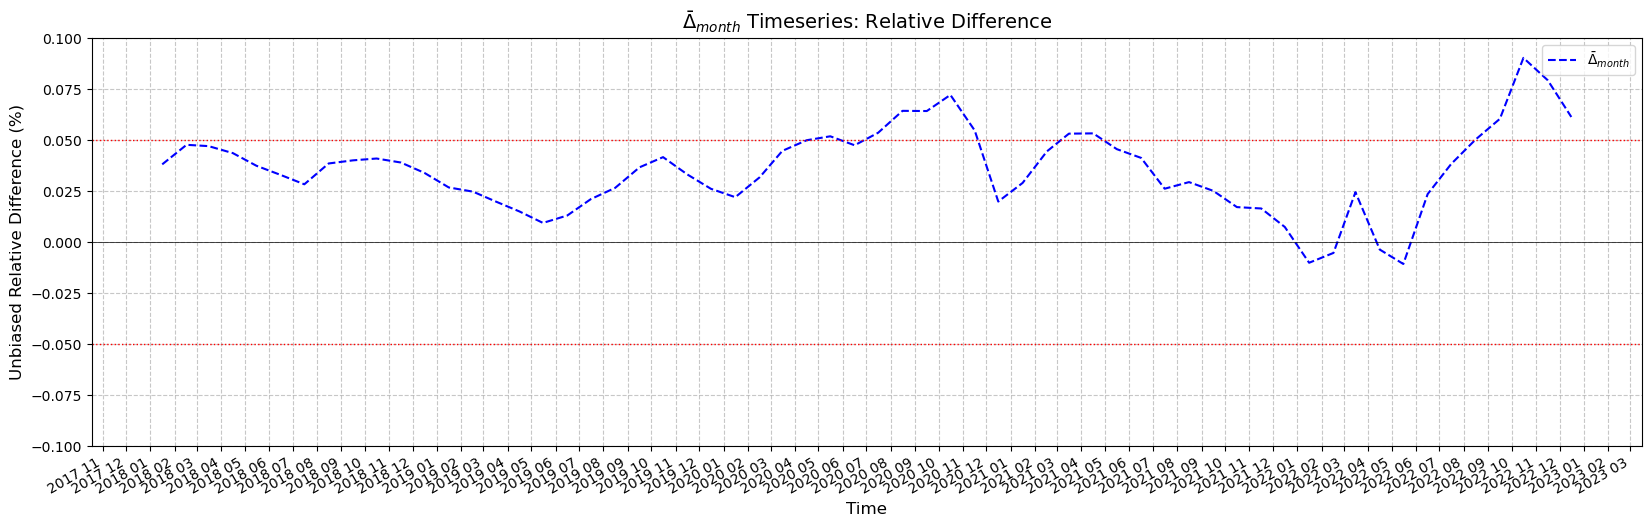

In [4]:
# Open the NetCDF file
delta_matrix_file = '/Users/madisonrichardson/netpp/data/noaa20/matrix/delta/netpp_delta_noaa20_modis.nc'
ds = xr.open_dataset(delta_matrix_file)
da = ds.delta

# Calculate monthly mean delta
delta_mean2 = da.mean(dim=["latitude", "longitude"], skipna=True)

# Adjust the time values to the 16th of each month
my_date = pd.to_datetime(da.time.values)
my_date = my_date.map(lambda x: x.replace(day=16))

# Create plot
plt.figure(figsize=(20, 6))
plt.plot(my_date, delta_mean2, 'b--', label=r'$\bar{\Delta}_{month}$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(0.05, color='red', linestyle=':', linewidth='1')
plt.axhline(-0.05, color='red', linestyle=':', linewidth='1')
plt.ylim(-0.1, 0.1)

# Add titles and labels
plt.title(r'$\bar{\Delta}_{month}$ Timeseries: Relative Difference', fontsize=14)
plt.ylabel('Unbiased Relative Difference (%)', fontsize=12)
plt.xlabel('Time', fontsize=12)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y %m'))  # Format as 'Year Month 

# Formatting the x-axis to be able to read easily
plt.gcf().autofmt_xdate()

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.legend()
plt.show()

<h2> Calculate and Plot Spatial Variability<h2>

<h3>Generate and plot Delta 5-year global map<h3>

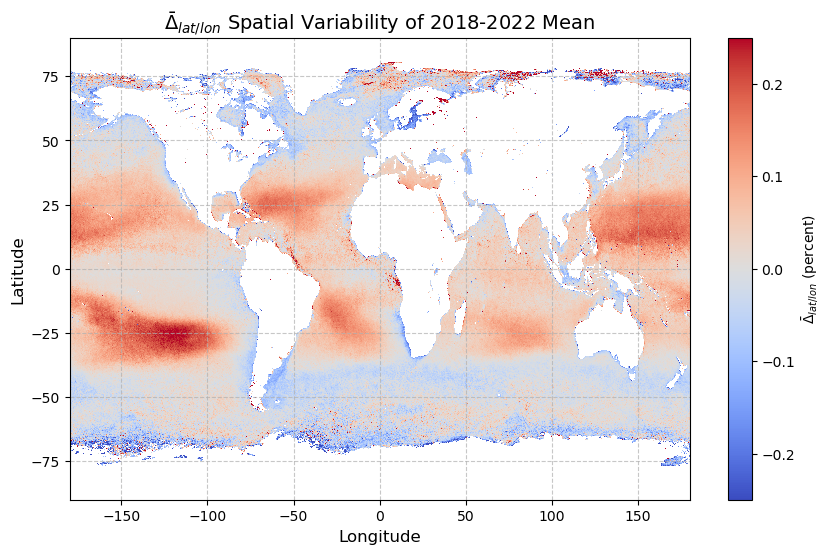

In [5]:
delta_matrix_file = '/Users/madisonrichardson/netpp/data/noaa20/matrix/delta/netpp_delta_noaa20_modis.nc'
ds = xr.open_dataset(delta_matrix_file)
da = ds.delta

# Center time on the 16th day of the month
time_centered = pd.to_datetime(da.time.values)
time_centered = time_centered.map(lambda x: x.replace(day=16))

# Assign the centered time back to the dataset
da['time'] = time_centered

delta_mean = da.mean(dim="time", skipna=True).values

# Plot the spatial variability as a 2D Map
plt.figure(figsize=(10, 6))

# Use color with a range from -20% to 20%
plt.pcolormesh(ds.longitude, ds.latitude, delta_mean, cmap='coolwarm', vmin=-.25, vmax=.25)

# Add a colorbar
cbar = plt.colorbar()
cbar.set_label(r'$\bar{\Delta}_{lat/lon}$ (percent)')

# Add labels and title
plt.title(r'$\bar{\Delta}_{lat/lon}$ Spatial Variability of 2018-2022 Mean', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## Monthly Timeseries Plot

In [ ]:
delta_matrix_file = '/Users/madisonrichardson/netpp/data/noaa20/matrix/delta/delta_3D_matrix_2018to2022.nc'
ds = xr.open_dataset(delta_matrix_file)
da = ds.delta
delta_mean = da.mean(dim=["latitude", "longitude"], skipna=True)
my_date = pd.to_datetime(da.time.values).map(lambda x: x.replace(day=16))
plot_monthly_delta_timeseries(my_date, delta_mean)

## Spatial Variability Plot

In [ ]:
plot_spatial_delta_mean(my_date, ds, da, title=r'$\bar{\Delta}_{lat/lon}$ Spatial Variability of 2018-2022 Mean')